In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Import the dataset

In [2]:
from tensorflow.keras.datasets import mnist

# Import all layers and flatten techniques

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Dataset

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


# Visualize Dataset

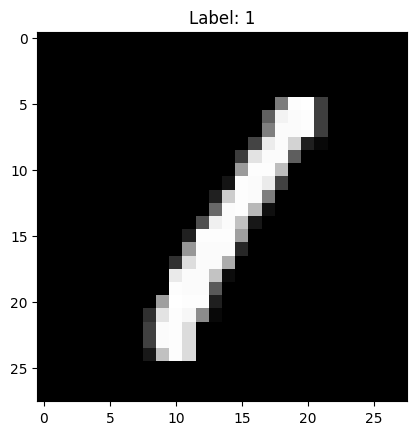

In [7]:
plt.imshow(x_train[3], cmap='gray')
plt.title(f"Label: {y_train[3]}")
plt.show()

# Normalize Data

In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9275 - loss: 0.2427
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9683 - loss: 0.1032
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9782 - loss: 0.0712
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9831 - loss: 0.0543
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9865 - loss: 0.0415


# Evaluate Model 

In [14]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9775 - loss: 0.0831
Accuracy: 0.9775000214576721


# Make Predictions

In [15]:
prediction = model.predict(x_test)

print(prediction[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[4.4876303e-09 4.7221889e-08 8.0375219e-07 3.4328949e-08 7.7367621e-13
 1.3903957e-10 5.6318890e-15 9.9999416e-01 6.7256467e-10 4.9744058e-06]


In [16]:
predicted_digit = np.argmax(prediction[0])

print("Predicted:", predicted_digit)
print("Actual:", y_test[0])

Predicted: 7
Actual: 7


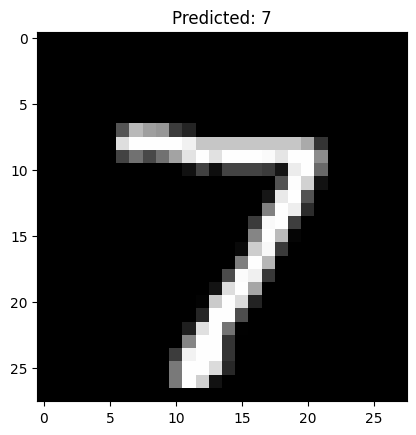

In [17]:
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.show()